# Task 4: Reranker Performance Comparison

In [1]:
import sys
sys.path.insert(0, '..')
sys.path.insert(0, '.')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from openai import OpenAI
import time

from eval_utils import load_questions, build_chunks, embed_chunks, summarize_results
from textwave.modules.extraction.embedding import Embedding
from textwave.modules.retrieval.index.bruteforce import BruteForceIndex
from textwave.modules.retrieval.reranker import Reranker
from textwave.modules.utils.metrics import Matching

questions = load_questions(deduplicate=True)
embedder = Embedding('all-MiniLM-L6-v2')
matcher = Matching()

BEST_STRATEGY = 'sentence'
BEST_PARAMS = dict(num_sentences=3, overlap_size=1)
RETRIEVE_K = 20
RERANK_K = 5

print('Building index...')
chunks, source_files = build_chunks(strategy=BEST_STRATEGY, **BEST_PARAMS)
embeddings = embed_chunks(chunks)
dim = embeddings.shape[1]
idx = BruteForceIndex(dim)
idx.add(embeddings, chunks)
print(f'Index ready: {idx.ntotal} chunks!')

/opt/anaconda3/envs/textwave311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6007.53it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Using device: cpu


Loading weights: 100%|██████████| 393/393 [00:00<00:00, 6861.85it/s]


Building index...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 12201.01it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Index ready: 17161 chunks!


In [2]:
class QAGeneratorRAG:
    def __init__(self, model: str, temperature: float = 0.3):
        self.model = model
        self.client = OpenAI(api_key='ollama', base_url='http://localhost:11434/v1')
        self.temperature = temperature

    def generate_answer(self, query: str, context: list) -> str:
        combined = f"Question: {query}\n\nContext: {', '.join(context)}"
        response = self.client.chat.completions.create(
            model=self.model,
            temperature=self.temperature,
            max_tokens=120,
            messages=[
                {
                    'role': 'system',
                    'content': (
                        'You must answer the user questions only based on the provided context. '
                        'Do not use any external or prior knowledge. '
                        'Provide clear, concise, and full-sentence answers. '
                        'If the context does not mention the answer, respond with "No context".'
                    ),
                },
                {'role': 'user', 'content': combined},
            ],
        )
        time.sleep(1)
        return response.choices[0].message.content.strip()

In [5]:
def run_reranker_experiment(model_name: str, reranker_type: str) -> pd.DataFrame:
    """
    For each question: retrieve -> rerank -> generate -> score.
    """
    generator = QAGeneratorRAG(model=model_name)
    if reranker_type != 'none':
        reranker = Reranker(type=reranker_type)
    rows = []

    grouped = questions.groupby('Question')
    for question, group in grouped:
        references = group['Answer'].tolist()
        difficulty = group['DifficultyFromAnswerer'].iloc[0]

        # Retrieve broad candidate set
        query_vec = embedder.encode(question)
        cand_chunks, cand_indices, _ = idx.search_with_indices(query_vec, RETRIEVE_K)

        # Rerank
        if reranker_type == 'none':
            context = cand_chunks[:RERANK_K]
        elif reranker_type == 'sequential':
            ranked_docs, ranked_idx, _ = reranker.rerank(
                question, cand_chunks, seq_k1=10, seq_k2=RERANK_K
            )
            context = ranked_docs[:RERANK_K]
        else:
            ranked_docs, ranked_idx, _ = reranker.rerank(question, cand_chunks)
            context = ranked_docs[:RERANK_K]

        # Generate
        try:
            answer = generator.generate_answer(query=question, context=context)
            em = matcher.exact_match(answer, references[0])
            scores, tm = matcher.transformer_match(answer, references[0], question)
            try:
                t_score = float(max(scores.values())) if scores else 0.0
            except (TypeError, ValueError, AttributeError):
                t_score = 0.0
        except Exception as e:
            answer, em, tm, t_score = '', 0, 0, 0.0
            print(f'Error: {e}')

        rows.append({
            'question': question,
            'generated_answer': answer,
            'difficulty': difficulty,
            'exact_match': int(em),
            'transformer_match': int(tm),
            'transformer_score': float(t_score) if not isinstance(t_score, dict) else 0.0,
        })

    return pd.DataFrame(rows)

print('Ready!')

Ready!


In [6]:
# Run all reranker experiments using the best model from Task 3 
BEST_MODEL = 'qwen2.5:1.5b'
reranker_types = ['none', 'tfidf', 'bow', 'cross_encoder', 'sequential']

task4_results = {}
for rtype in reranker_types:
    print(f'\nRunning {rtype} reranker with {BEST_MODEL}...')
    results = run_reranker_experiment(BEST_MODEL, rtype)
    results.to_csv(f'results_task4_{rtype}.csv', index=False)
    task4_results[rtype] = results
    overall = results['transformer_match'].mean()
    print(f'  Overall TM: {overall:.4f}')

print('\nDone!')


Running none reranker with qwen2.5:1.5b...
Error: object of type 'float' has no len()
Error: RobertaTokenizer has no attribute encode_plus
Error: object of type 'float' has no len()
Error: object of type 'float' has no len()
Error: object of type 'float' has no len()
Error: RobertaTokenizer has no attribute encode_plus
Error: object of type 'float' has no len()
Error: object of type 'float' has no len()
Error: RobertaTokenizer has no attribute encode_plus
Error: object of type 'float' has no len()
Error: RobertaTokenizer has no attribute encode_plus
Error: object of type 'float' has no len()
Error: object of type 'float' has no len()
Error: RobertaTokenizer has no attribute encode_plus
Error: RobertaTokenizer has no attribute encode_plus
Error: RobertaTokenizer has no attribute encode_plus
Error: object of type 'float' has no len()
Error: RobertaTokenizer has no attribute encode_plus
Error: RobertaTokenizer has no attribute encode_plus
Error: object of type 'float' has no len()
Error:

Loading weights: 100%|██████████| 41/41 [00:00<00:00, 8970.14it/s]
BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-TinyBERT-L-2-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Error: object of type 'float' has no len()
Error: RobertaTokenizer has no attribute encode_plus
Error: object of type 'float' has no len()
Error: object of type 'float' has no len()
Error: object of type 'float' has no len()
Error: object of type 'float' has no len()
Error: object of type 'float' has no len()
Error: RobertaTokenizer has no attribute encode_plus
Error: object of type 'float' has no len()
Error: RobertaTokenizer has no attribute encode_plus
Error: object of type 'float' has no len()
Error: object of type 'float' has no len()
Error: RobertaTokenizer has no attribute encode_plus
Error: RobertaTokenizer has no attribute encode_plus
Error: RobertaTokenizer has no attribute encode_plus
Error: object of type 'float' has no len()
Error: RobertaTokenizer has no attribute encode_plus
Error: RobertaTokenizer has no attribute encode_plus
Error: object of type 'float' has no len()
Error: object of type 'float' has no len()
Error: RobertaTokenizer has no attribute encode_plus
Error: 

Loading weights: 100%|██████████| 41/41 [00:00<00:00, 7063.15it/s]
BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-TinyBERT-L-2-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Error: object of type 'float' has no len()
Error: RobertaTokenizer has no attribute encode_plus
Error: object of type 'float' has no len()
Error: object of type 'float' has no len()
Error: object of type 'float' has no len()
Error: object of type 'float' has no len()
Error: object of type 'float' has no len()
Error: RobertaTokenizer has no attribute encode_plus
Error: object of type 'float' has no len()
Error: RobertaTokenizer has no attribute encode_plus
Error: RobertaTokenizer has no attribute encode_plus
Error: RobertaTokenizer has no attribute encode_plus
Error: RobertaTokenizer has no attribute encode_plus
Error: object of type 'float' has no len()
Error: object of type 'float' has no len()
Error: RobertaTokenizer has no attribute encode_plus
Error: RobertaTokenizer has no attribute encode_plus
Error: RobertaTokenizer has no attribute encode_plus
Error: RobertaTokenizer has no attribute encode_plus
Error: object of type 'float' has no len()
Error: RobertaTokenizer has no attribute

Loading weights: 100%|██████████| 41/41 [00:00<00:00, 8336.96it/s]
BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-TinyBERT-L-2-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Error: object of type 'float' has no len()
Error: RobertaTokenizer has no attribute encode_plus
Error: object of type 'float' has no len()
Error: object of type 'float' has no len()
Error: object of type 'float' has no len()
Error: object of type 'float' has no len()
Error: object of type 'float' has no len()
Error: RobertaTokenizer has no attribute encode_plus
Error: object of type 'float' has no len()
Error: RobertaTokenizer has no attribute encode_plus
Error: RobertaTokenizer has no attribute encode_plus
Error: object of type 'float' has no len()
Error: object of type 'float' has no len()
Error: RobertaTokenizer has no attribute encode_plus
Error: RobertaTokenizer has no attribute encode_plus
Error: object of type 'float' has no len()
Error: RobertaTokenizer has no attribute encode_plus
Error: object of type 'float' has no len()
Error: object of type 'float' has no len()
Error: RobertaTokenizer has no attribute encode_plus
Error: RobertaTokenizer has no attribute encode_plus
Error: 

Loading weights: 100%|██████████| 41/41 [00:00<00:00, 13666.57it/s]
BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-TinyBERT-L-2-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Error: object of type 'float' has no len()
Error: RobertaTokenizer has no attribute encode_plus
Error: object of type 'float' has no len()
Error: object of type 'float' has no len()
Error: object of type 'float' has no len()
Error: RobertaTokenizer has no attribute encode_plus
Error: object of type 'float' has no len()
Error: object of type 'float' has no len()
Error: RobertaTokenizer has no attribute encode_plus
Error: object of type 'float' has no len()
Error: RobertaTokenizer has no attribute encode_plus
Error: RobertaTokenizer has no attribute encode_plus
Error: object of type 'float' has no len()
Error: object of type 'float' has no len()
Error: RobertaTokenizer has no attribute encode_plus
Error: RobertaTokenizer has no attribute encode_plus
Error: object of type 'float' has no len()
Error: RobertaTokenizer has no attribute encode_plus
Error: object of type 'float' has no len()
Error: object of type 'float' has no len()
Error: RobertaTokenizer has no attribute encode_plus
Error: 

In [9]:
# Summary table
rows = []
for rtype, df in task4_results.items():
    rows.append({
        'Reranker': rtype,
        'Overall TM': df['transformer_match'].mean(),
        'Easy TM': df[df['difficulty']=='easy']['transformer_match'].mean(),
        'Medium TM': df[df['difficulty']=='medium']['transformer_match'].mean(),
        'Hard TM': df[df['difficulty']=='hard']['transformer_match'].mean(),
    })

# Also add task 2 baseline for comparison
try:
    t2 = pd.read_csv(f'results_task2_{BEST_MODEL.replace(":", "_")}.csv')
    rows.insert(0, {
        'Reranker': 'baseline (no RAG)',
        'Overall TM': t2['transformer_match'].mean(),
        'Easy TM': t2[t2['difficulty']=='easy']['transformer_match'].mean(),
        'Medium TM': t2[t2['difficulty']=='medium']['transformer_match'].mean(),
        'Hard TM': t2[t2['difficulty']=='hard']['transformer_match'].mean(),
    })
except: pass

summary_table = pd.DataFrame(rows)
print('\nTable: Reranker Performance Comparison')
print(summary_table.to_string(index=False))


Table: Reranker Performance Comparison
         Reranker  Overall TM  Easy TM  Medium TM  Hard TM
baseline (no RAG)    0.293461 0.574766   0.206897 0.231579
             none    0.449761 0.719626   0.528736 0.347368
            tfidf    0.468900 0.757009   0.563218 0.336842
              bow    0.449761 0.733645   0.517241 0.336842
    cross_encoder    0.480064 0.775701   0.574713 0.347368
       sequential    0.473684 0.780374   0.551724 0.326316


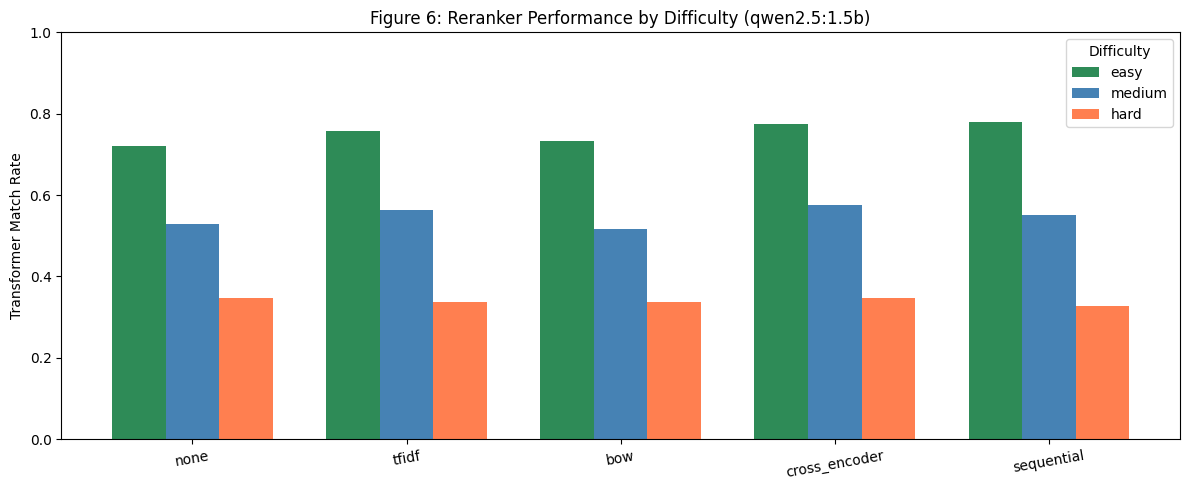

In [10]:
# Figure: reranker performance by difficulty
diffs = ['easy', 'medium', 'hard']
fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(reranker_types))
width = 0.25
colors = ['seagreen', 'steelblue', 'coral']

for i, diff in enumerate(diffs):
    scores = [
        task4_results[rt][task4_results[rt]['difficulty']==diff]['transformer_match'].mean()
        for rt in reranker_types
    ]
    ax.bar([xi + i*width for xi in x], scores, width, label=diff, color=colors[i])

ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels(reranker_types, rotation=10)
ax.set_ylabel('Transformer Match Rate')
ax.set_ylim(0, 1)
ax.legend(title='Difficulty')
ax.set_title(f'Figure 6: Reranker Performance by Difficulty ({BEST_MODEL})')
plt.tight_layout()
plt.savefig('figures/task4_reranker_comparison.png', dpi=150)
plt.show()